In [1]:
import json
import requests
import pandas as pd
import numpy as np

from datetime import datetime
from datetime import date, timedelta
from dateutil.relativedelta import relativedelta
from datetime import date

import matplotlib.pyplot as plt 
import matplotlib.ticker as ticker
from matplotlib.dates import DateFormatter

import eurostat #python wrapper for taking data. 
import time

In [36]:
Share_point = r'C:\Users\giovanni.sgaravatti\Bruegel\Research - 2021-11 European natural gas imports\Data\Storage'

In [37]:
import os
os.chdir(Share_point)

In [4]:
os.getcwd()

'C:\\Users\\giovanni.sgaravatti\\Bruegel\\Research - 2021-11 European natural gas imports\\Data\\Storage'

In [5]:
Points_APIs = pd.read_excel(r'Storage_facilities_API_call.xlsx')

### Version 5 of the API calls GIE

In [6]:
# AGI_APIs = pd.read_excel(r'C:\Users\giovanni.sgaravatti\OneDrive - Bruegel\Documents\Gas flow model\AGSI storage\SSO_EIC excel.xlsx')

In [7]:
# Points_APIs = pd.read_excel(r'C:\Users\giovanni.sgaravatti\OneDrive - Bruegel\Documents\Gas flow model\AGSI storage\SSO_EIC 30.11.2021 excel.xlsx',sheet_name='Sheet2')
# Points_APIs.head(2)
# Points_APIs.iloc[1,6]
# headers = {"x-key":"c004438249338e49ed35e0ffce94cb6a"}

####### Date 
2022-02-25 00:00:00

We are pleased to announce that EDF Gas Deutschland GmbH and EnBW Etzel Speicher GmbH are joining AGSI+ for publication of their share in the jointly operated storage facility in Etzel, Germany.

This joint publication replaces the dataset entry for Crystal, Friedeburger Speicherbetriebsgesellschaft mbH (EIC 21X000000001125L) previously listed for UGS Oude Statenzijl Etzel Crystal (EIC 21W000000000013E)

Crystal is the Joint Venture between EDF Gas Deutschland GmbH and EnBW Etzel Speicher GmbH to operate the storage facility in Etzel, Germany.

The designated SSOs (EDF Gas Deutschland GmbH and EnBW Etzel Speicher GmbH) are each reporting for their share in the Etzel storage facility.

### Version 6 of the API calls GIE

In [7]:
headers = {"x-key":"d8561648296cb38e6c400823755689941530"} # After July 4th 2022

### Can skip now

In [8]:
url_list = 'http://agsi.gie.eu/api/about?show=listing'
r_list = requests.get(url_list,headers=headers)
storage_list = r_list.json()

In [9]:
name = []
UGS_type = []
eic =[]
country = []
company = []
url = []

In [10]:
for item in storage_list:
    for facility in item['facilities']:
        name_f = facility['name']
        UGS_type_f = facility['type']
        eic_f = facility['eic']
        country_f = facility['country']
        company_f = facility['company']
        url_f = facility['url']
        
        name.append(name_f)
        UGS_type.append(UGS_type_f)
        eic.append(eic_f)
        country.append(country_f)
        company.append(company_f)
        url.append(url_f)

In [11]:
storage_list_df = pd.DataFrame()
storage_list_df['name']=name
storage_list_df['type']=UGS_type
storage_list_df['eic']=eic
storage_list_df['country']=country
storage_list_df['company_eic']=company
storage_list_df['url']=url

In [12]:
storage_list_df.to_excel('Storage_facilities_API_call.xlsx')

### Restart here

In [13]:
dates = []
values = []
injection = []
withdrawal =[]
percentage = []
status = []
max_storage = []
country = []
Name = []

for item in range(len(Points_APIs)):
        url = Points_APIs.iloc[item,6]+'&from=2022-07-01&size=300'
        try:
            r = requests.get(url,headers=headers)
            if r.status_code != 200:
                print(r.status_code)
                print(url)

            raw_data = r.json()
            inner_data = raw_data['data']
            for x in inner_data:
                #here we work with the APIs
#                 date = x['gasDayStartedOn']     # Changed on 5 April 2022
                date = x['gasDayStart']
                value = x['gasInStorage']
                inj = x['injection']
                withdr = x['withdrawal']
                percentages = x['full']
                statuses = x['status']
                Max_Storage = x['workingGasVolume']
                #here we work with the excel file
                countries = Points_APIs.iloc[item,4]
                Names = Points_APIs.iloc[item,1]


                dates.append(date)     
                values.append(value)
                injection.append(inj)
                withdrawal.append(withdr)
                percentage.append(percentages)
                status.append(statuses)
                max_storage.append(Max_Storage)
                country.append(countries)
                Name.append(Names)
        except Exception as e:
            print(e)

In [31]:
df = pd.DataFrame()
df['dates'] = dates
df['values'] = values
df['injection'] = injection
df['withdrawal'] = withdrawal
df['fillness'] = percentage
df['status'] = status
df['Max Storage'] = max_storage
df['country'] = country
df['name'] = Name

In [32]:
# Getting rid of NaNa
df.replace('', np.NaN)
# Getting rid of observations for which we have no data
df = df[df['status']!='N']

In [33]:
df['values'] = pd.to_numeric(df['values']) 
df['fillness'] = pd.to_numeric(df['fillness'])
df['Max Storage'] = pd.to_numeric(df['Max Storage']) 

In [38]:
from datetime import date
df.to_csv('Storage all from 2015/historic data/2022_2.csv')

###  merge with historic data

In [39]:
# df = pd.read_csv(r'C:\Users\giovanni.sgaravatti\Documents\Gas flow model\AGSI storage\storage all.csv')
# df = pd.read_csv('storage all from 2015/{}.csv'.format(date.today()))

In [40]:
# Change current directory
import os
os.chdir(Share_point + '\Storage all from 2015\historic data')

In [41]:
df_1a = pd.read_csv('2015_1.csv',index_col=0)
df_1b = pd.read_csv('2015_2.csv',index_col=0)
df_2a = pd.read_csv('2016_1.csv',index_col=0)
df_2b = pd.read_csv('2016_2.csv',index_col=0)
df_3a = pd.read_csv('2017_1.csv',index_col=0)
df_3b = pd.read_csv('2017_2.csv',index_col=0)
df_4a = pd.read_csv('2018_1.csv',index_col=0)
df_4b = pd.read_csv('2018_2.csv',index_col=0)
df_5a = pd.read_csv('2019_1.csv',index_col=0)
df_5b = pd.read_csv('2019_2.csv',index_col=0)
df_6a = pd.read_csv('2020_1.csv',index_col=0)
df_6b = pd.read_csv('2020_2.csv',index_col=0)
df_7a = pd.read_csv('2021_1.csv',index_col=0)
df_7b = pd.read_csv('2021_2.csv',index_col=0)
df_8a = pd.read_csv('2022_1.csv',index_col=0)
df_8b = pd.read_csv('2022_2.csv',index_col=0)

In [42]:
df = pd.concat([df_1a,df_1b,df_2a,df_2b,df_3a,df_3b,df_4a,df_4b,df_5a,df_5b,df_6a,df_6b,df_7a,df_7b,df_8a,df_8b])

In [43]:
# del df['Unnamed: 0']
df = df.drop_duplicates()

In [44]:
# This doesn't work Unable to parse string "-" at position 11862
# Getting rid of observations for which we have no data
#df = df[(df['status']!='N') & (df['status']!='E')]
df = df[(df['status']!='N')]
# Getting rid of NaNa
df.replace('', np.NaN)  #we try to set missing values to the numpy notation, NaN - easier to work with. 
df.replace('-', np.NaN)
# #We need to set it to integer to work with. 
#Using coerce we actually set missing values to the numpy notation, NaN - easier to work with. 
df['values'] = pd.to_numeric(df['values'],errors='coerce')  
df['injection'] = pd.to_numeric(df['injection'],errors='coerce') 
df['withdrawal'] = pd.to_numeric(df['withdrawal'],errors='coerce') 
df['fillness'] = pd.to_numeric(df['fillness'],errors='coerce') 
df['Max Storage'] = pd.to_numeric(df['Max Storage'],errors='coerce') 

In [45]:
df[(df['name'] == 'UGS Katharina')& (df['dates']=='2023-01-22')]

,dates,values,injection,withdrawal,fillness,status,Max Storage,country,name
9595,2023-01-22,6.1364,0.0,1.7,100.0,C,6.1346,DE,UGS Katharina


In [46]:
non_EU = ['UA','RS']

In [47]:
# Getting rid of non-EU countries, Ukraine shows crazy numbers
df=df[~df.country.isin(non_EU)]

In [48]:
df = df.set_index(pd.DatetimeIndex(df['dates']))

In [49]:
del df['dates']

In [50]:
df = df.sort_values(by='dates')

In [51]:
df

,values,injection,withdrawal,fillness,status,Max Storage,country,name
dates,,,,,,,,
2015-01-01,1.4654,0.00,14.8,92.75,C,1.5800,DE,UGS Lesum
2015-01-01,10.5282,0.00,0.6,79.76,C,13.2000,PL,UGS Wierzchowice
2015-01-01,6.9043,0.00,15.2,77.82,C,8.8722,BE,UGS Loenhout
2015-01-01,0.0000,0.00,0.0,0.00,C,0.0000,DE,UGS Epe (KGE)
2015-01-01,9.7547,1.37,68.8,64.51,C,15.1222,AT,"RAG Storage Pool (Puchkirchen / Haag, Aigelsbr..."
...,...,...,...,...,...,...,...,...
2023-04-23,3.3479,16.80,0.0,81.17,C,4.1245,DE,UGS Wolfersberg
2023-04-23,0.6536,6.45,0.0,67.54,C,0.9677,DE,UGS Frankenthal
2023-04-23,3.8390,0.00,0.0,76.78,C,5.0000,NL,UGS Alkmaar


# Gazprom

In [52]:
# Change current directory
import os
os.chdir(Share_point)

Gazprom holds stocks at 
Haidach in Austria (via its wholly owned subsidiaries, Astora and GSA),
Dambořice in the Czech Republic (via its subsidiary, Moravia Gas Storage), 
Bergermeer in the Netherlands (where Gazprom holds 19 TWh of capacity in the 48 TWh capacity facility through partnership with TAQA), 
and at Jemgum and Rehden (via Astora) in Germany. 

In addition, Gazprom has access to half the capacity at
Katharina in Germany (via Astora) and
one third of the capacity held at Etzel in Germany by EKB (Gazprom being a 33 per cent shareholder in EKB).

Data on AGSI+ are provided in Twh therefore to convert in M3m we have to multiply by103

In [53]:
Gazprom_grouped = ['UGS Jemgum H (astora)', 'UGS Jemgum H (VGS)',
                   'UGS Jemgum H (EWE)', # 26.04 addition 
                   #'UGS Katharina',
                   'UGS Rehden',
                   'UGS Haidach (astora)', 'UGS Haidach (GSA)',
                   'UGS Dambořice']

In [54]:
EU_Gazprom = df[df['name'].isin(Gazprom_grouped)]
EU_Gazprom['name'].unique()

array(['UGS Rehden', 'UGS Jemgum H (EWE)', 'UGS Haidach (astora)',
       'UGS Haidach (GSA)', 'UGS Jemgum H (astora)', 'UGS Dambořice',
       'UGS Jemgum H (VGS)'], dtype=object)

In [55]:
EU_Gazprom.tail(7)

,values,injection,withdrawal,fillness,status,Max Storage,country,name
dates,,,,,,,,
2023-04-23,5.7730,27.37,0.0,71.14,C,8.1150,DE,UGS Jemgum H (astora)
2023-04-23,0.5533,11.23,0.0,34.47,C,1.6055,DE,UGS Jemgum H (VGS)
2023-04-23,0.0000,0.00,0.0,0.00,C,0.0000,AT,UGS Haidach (GSA)
2023-04-23,36.9264,149.94,0.0,82.67,C,44.6682,DE,UGS Rehden
2023-04-23,2.0963,14.83,0.2,43.73,C,4.7936,CZ,UGS Dambořice
2023-04-23,0.9581,0.00,0.0,28.16,C,3.4019,DE,UGS Jemgum H (EWE)
2023-04-23,14.0747,80.31,0.0,75.64,C,18.6080,AT,UGS Haidach (astora)


In [56]:
EU_Gazprom.to_excel('Gazprom daily/EU_Gazprom_raw.xlsx')

In [57]:
#This creates dataframe for looking at Gazprom in TWh. 
EU_Gazprom = EU_Gazprom.groupby(["dates"])["values",'injection','withdrawal','Max Storage'].sum().reset_index()
EU_Gazprom = EU_Gazprom.set_index(pd.DatetimeIndex(EU_Gazprom['dates']))

C:\Users\giovanni.sgaravatti\AppData\Local\Temp\ipykernel_22176\360016554.py:2: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  EU_Gazprom = EU_Gazprom.groupby(["dates"])["values",'injection','withdrawal','Max Storage'].sum().reset_index()


In [58]:
del EU_Gazprom['dates']

In [59]:
EU_Gazprom.groupby(["dates"])["values",'injection','withdrawal','Max Storage'].sum().reset_index()

C:\Users\giovanni.sgaravatti\AppData\Local\Temp\ipykernel_22176\3349049674.py:1: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  EU_Gazprom.groupby(["dates"])["values",'injection','withdrawal','Max Storage'].sum().reset_index()


,dates,values,injection,withdrawal,Max Storage
0,2015-01-01,51.9115,0.00,491.4,60.3660
1,2015-01-02,51.4091,3.57,506.1,60.3660
2,2015-01-03,51.0028,0.00,406.2,60.3660
3,2015-01-04,50.5496,0.72,453.9,60.3660
4,2015-01-05,50.0242,0.00,525.4,60.3660
...,...,...,...,...,...
3030,2023-04-19,59.7122,117.32,13.6,81.1922
3031,2023-04-20,59.7072,73.60,78.4,81.1922
3032,2023-04-21,59.8253,141.13,23.0,81.1922
3033,2023-04-22,60.0987,274.01,0.4,81.1922


In [60]:
#check for inconsistencies in the graph
EU_Gazprom['daily flow'] = EU_Gazprom['injection']-EU_Gazprom['withdrawal'] 

In [61]:
# EU_Gazprom['daily flow']['2021-11-22':'2021-12-05']
# last_data = EU_Gazprom[EU_Gazprom['dates']>='2021-11-15']

In [62]:
converter=0.0103
converter_GWh = converter/1000

In [63]:
EU_Gazprom['storage in M3m'] = EU_Gazprom['values']/converter
EU_Gazprom['injection in M3m'] = EU_Gazprom['injection']/converter_GWh
EU_Gazprom['withdrawal in M3m'] = EU_Gazprom['withdrawal']/converter_GWh
EU_Gazprom['daily flow in M3m'] = EU_Gazprom['daily flow']/converter_GWh
EU_Gazprom['Max Storage in M3m'] = EU_Gazprom['Max Storage']/converter

In [64]:
EU_Gazprom['Max Storage in M3m']['2022-05-19']

8686.203883495145

In [65]:
# Daily data for Gazprom

In [66]:
from datetime import date
EU_Gazprom.to_csv('Gazprom daily/Daily_flows_Gazprom {}.csv'.format(date.today()))
# last_data.to_csv('Gazprom last data by point.csv')

In [67]:
# Weekly data

In [68]:
GazpromPlot = EU_Gazprom.groupby(pd.Grouper(freq='W')).mean()

In [69]:
# GazpromPlot.to_csv('Gazprom weekly\weekly_flows_Gazprom {}.csv'.format(date.today()))

In [70]:
import os
os.getcwd()

'C:\\Users\\giovanni.sgaravatti\\Bruegel\\Research - 2021-11 European natural gas imports\\Data\\Storage'

## Graphs

# Last 30 days comparison

In [71]:
del EU_Gazprom['injection']
del EU_Gazprom['withdrawal']
del EU_Gazprom['daily flow']
del EU_Gazprom['storage in M3m'] 
del EU_Gazprom['injection in M3m']
del EU_Gazprom['withdrawal in M3m']
del EU_Gazprom['daily flow in M3m']
del EU_Gazprom['Max Storage in M3m']
del EU_Gazprom['Max Storage']

### Old values (2015-2020)

In [72]:
# Here we get the dates and values for the last 30 days in all last 5 years (ex. 5 Oct to 5 Nov in 2015 to 2020)

gas = []
dates = []

from datetime import date
today = date.today()
month_str = str(today.month)
day_str = str(today.day)
from pandas.tseries.offsets import DateOffset

# for year in ['2015','2016','2017','2018','2019','2020']: ### not working cause we don't have data for 2014
for year in ['2016','2017','2018','2019','2020']:
    old_date = year+'-'+month_str+'-'+day_str
    old_date = pd.to_datetime(old_date)
    month_int = int(today.month)
#     date_less_30 = old_date - DateOffset(month=month_int-1)   ### not working in January
    date_less_30 = old_date - timedelta(days=30)
    old_date = old_date.date()
    date_less_30 = date_less_30.date()
    old_values_Mm3 = EU_Gazprom[date_less_30:old_date]['values']
    date_index = EU_Gazprom[date_less_30:old_date].index #['dates']
    gas.append(old_values_Mm3)
    dates.append(date_index)

In [73]:
# n_years = [0,1,2,3,4,5]
n_years = [0,1,2,3,4]
n_days = [*range(0, 30, 1)]

values = []
days = []

for i in n_years:
    for j in n_days:
        values.append(gas[i][j])
        days.append(dates[i][j])

In [74]:
d = {'days':days,'values':values}
df_old_Gazprom = pd.DataFrame(d)

In [75]:
# 5-year average dataframe
df_old_Gazprom = df_old_Gazprom.set_index(pd.DatetimeIndex(df_old_Gazprom['days']))
del df_old_Gazprom['days']
df_old_Gazprom['day and month'] = df_old_Gazprom.index.astype(str).str[5:]

In [76]:
# minvalues_Mm3 = df_old.groupby("daily").min()/converter
# maxvalues_Mm3 = df_old.groupby("daily").max()/converter
avgvalues = df_old_Gazprom.groupby("day and month").mean()/converter #last 5-year average for Gazprom daily data

### Last 30 days

In [77]:
# I create a new dataframe to work with it later and to distinguish it from the one with old values (5-year avgs)
EU_Gazprom_30 = EU_Gazprom.iloc[-31:]
# I add a daily column, like for the otehr dataframe
EU_Gazprom_30['day and month'] = EU_Gazprom_30.index.astype(str).str[5:]
#convert from TWh to M3m
EU_Gazprom_30['M3m values'] = EU_Gazprom_30['values']/converter

C:\Users\giovanni.sgaravatti\AppData\Local\Temp\ipykernel_22176\1902115508.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  EU_Gazprom_30['day and month'] = EU_Gazprom_30.index.astype(str).str[5:]
C:\Users\giovanni.sgaravatti\AppData\Local\Temp\ipykernel_22176\1902115508.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  EU_Gazprom_30['M3m values'] = EU_Gazprom_30['values']/converter


In [78]:
# del EU_Gazprom_30['dates']
del EU_Gazprom_30['values']

In [79]:
values_30_days = EU_Gazprom_30.groupby("day and month").max()

In [80]:
per_of_avg = (values_30_days['M3m values']/avgvalues['values'])*100
per_of_avg = per_of_avg.to_frame()
# Rename the column but unsuccessfully
per_of_avg.rename(columns={per_of_avg.columns[0]: 'Ratio'}, errors="raise", inplace=True)

In [81]:
# Create a Pandas Excel writer using XlsxWriter as the engine and save average and 2021 values.
from datetime import date

writer = pd.ExcelWriter(r'Gazprom daily/Gazprom {}.xlsx'.format(date.today()), engine='xlsxwriter')

# Write each dataframe to a different worksheet.
avgvalues.to_excel(writer, sheet_name='average')
values_30_days.to_excel(writer, sheet_name='2021')
per_of_avg.to_excel(writer, sheet_name='gazprom_2021_ratio')
EU_Gazprom_30.iloc[-30:].to_excel(writer, sheet_name='dataset')
writer.save()

C:\Users\giovanni.sgaravatti\AppData\Local\Temp\ipykernel_22176\269656448.py:11: FutureWarning: save is not part of the public API, usage can give unexpected results and will be removed in a future version
  writer.save()


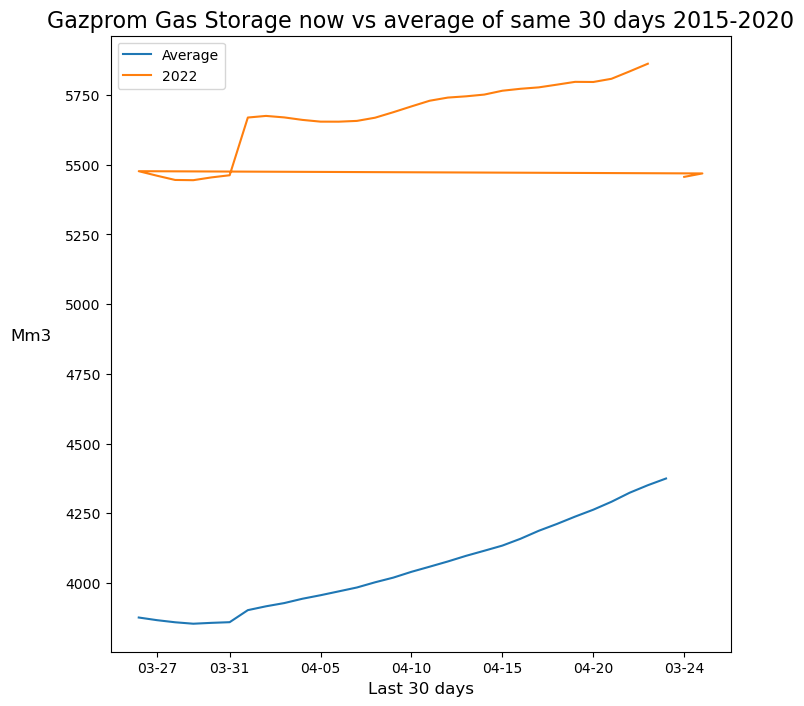

In [82]:
fig, ax = plt.subplots(figsize=(8, 8))

# ax.plot(minvalues_Mm3,label='Minimum')
# ax.plot(maxvalues_Mm3,label='Maximum')
ax.plot(avgvalues,label='Average')
ax.plot(values_30_days['M3m values'],label='2022')

plt.title('Gazprom Gas Storage now vs average of same 30 days 2015-2020',fontsize='16')
plt.ylabel('Mm3',fontsize=12,rotation=0,labelpad=25)
plt.xlabel('Last 30 days',fontsize=12,rotation=0)
tick_val = [1,5,10,15,20,25,30]
plt.xticks(tick_val)
plt.legend()
plt.show()
fig.savefig('figures/Gazprom storage.png',dpi=300,bbox_inches="tight")

# All series by week/month

In [83]:
GazpromPlot = EU_Gazprom.groupby(pd.Grouper(freq='W')).mean()

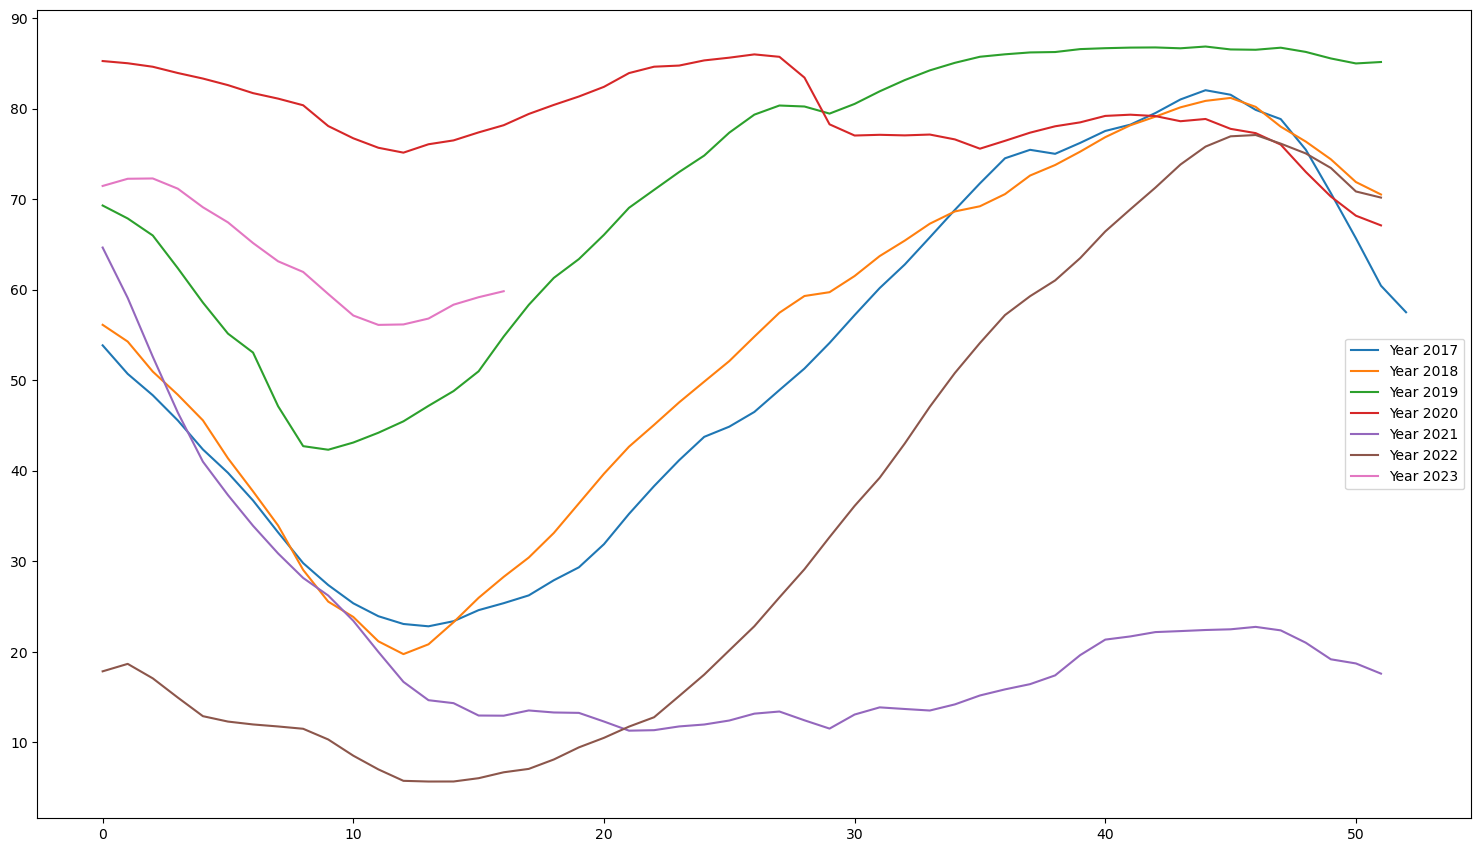

In [84]:
fig, ax = plt.subplots()
fig.set_size_inches(18.5, 10.5)
for yr in ['2017','2018','2019','2020','2021','2022','2023']:
    ax.plot(GazpromPlot.loc[yr].values, label = 'Year {}'.format(yr))
    plt.legend(loc='best')

# Gazprom charts min/max 2021 both in M3m and TWh

In [85]:
#compare by week or month
compare = 'weekly'

In [86]:
GazpromPlot[compare] = GazpromPlot.index.isocalendar().week

In [87]:
from datetime import date
today = date.today()
minvalues_Mm3 = GazpromPlot['2015-01-01':'2019-12-29'].groupby(compare).min()/converter
maxvalues_Mm3 = GazpromPlot['2015-01-01':'2019-12-29'].groupby(compare).max()/converter
avgvalues = GazpromPlot['2015-01-01':'2019-12-29'].groupby(compare).mean()/converter
# values2021_Mm3 = GazpromPlot['2020-12-28':'{}'.format(today)].groupby(compare).last()/converter
values2021_Mm3 = GazpromPlot['2020-12-28':'2022-01-02'].groupby(compare).last()/converter  #from week 1 to 53 of 2021
values2022_Mm3 = GazpromPlot['2022-01-03':'2023-01-01'].groupby(compare).last()/converter  #from week 1 to 53 of 2021
values2023_Mm3 = GazpromPlot['2023-01-02':].groupby(compare).last()/converter  #from week 1 to 53 of 2021

In [88]:
# values2022_Mm3
values2023_Mm3

,values
weekly,
1,7015.246879
2,7018.589459
3,6908.875173
4,6709.740638
5,6547.558946
6,6326.054092
7,6130.102635
8,6015.776699
9,5779.238558


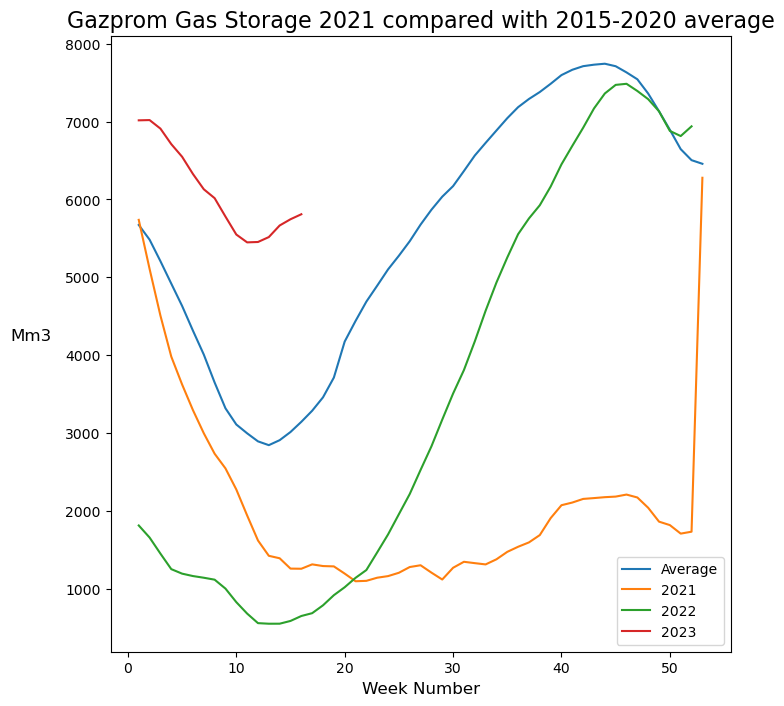

In [89]:
fig, ax = plt.subplots(figsize=(8, 8))

# ax.plot(minvalues_Mm3,label='Minimum')
# ax.plot(maxvalues_Mm3,label='Maximum')
ax.plot(avgvalues,label='Average')
ax.plot(values2021_Mm3,label='2021')
ax.plot(values2022_Mm3,label='2022')
ax.plot(values2023_Mm3,label='2023')

plt.title('Gazprom Gas Storage 2021 compared with 2015-2020 average',fontsize='16')
plt.ylabel('Mm3',fontsize=12,rotation=0,labelpad=25)
plt.xlabel('Week Number',fontsize=12,rotation=0)
plt.legend()
plt.show()
fig.savefig('figures/Gazprom storage.png',dpi=300,bbox_inches="tight")

In [90]:
# Create a Pandas Excel writer using XlsxWriter as the engine and save average and 2021 values.
# from datetime import date
# writer = pd.ExcelWriter(r'Gazprom weekly/Gazprom Storage weekly {}.xlsx'.format(date.today()), engine='xlsxwriter')

# # Write each dataframe to a different worksheet.
# minvalues_Mm3.round(1).to_excel(writer, sheet_name='Min')
# maxvalues_Mm3.round(1).to_excel(writer, sheet_name='Max')
# values2021_Mm3.round(1).to_excel(writer, sheet_name='2021')
# values2022_Mm3.round(1).to_excel(writer, sheet_name='2022')

# writer.save()
# writer.close()

#### Save excel for infogram

In [91]:
GZ_weekly = pd.DataFrame()
GZ_weekly['minvalues'] = minvalues_Mm3.round(1)
GZ_weekly['maxvalues'] = maxvalues_Mm3.round(1)
GZ_weekly['2021'] = values2021_Mm3.round(1)
GZ_weekly['2022'] = values2022_Mm3.round(1)
GZ_weekly['2023'] = values2023_Mm3.round(1)
GZ_weekly.to_excel(r'Gazprom weekly/Gazprom Storage weekly {}.xlsx'.format(date.today()))

In [92]:
minvalues = GazpromPlot['2015-01-05':'2019-12-29'].groupby(compare).min()
maxvalues = GazpromPlot['2015-01-05':'2019-12-29'].groupby(compare).max()
# avgvalues = GazpromPlot['2015-01-05':'2020'].groupby(compare).mean()
values2021 = GazpromPlot.loc['2021-01-05':'2022-01-02'].groupby(compare).mean()
values2022 = GazpromPlot.loc['2022-01-02':'2023-01-01'].groupby(compare).mean()
values2023 = GazpromPlot.loc['2022-01-02':].groupby(compare).mean()

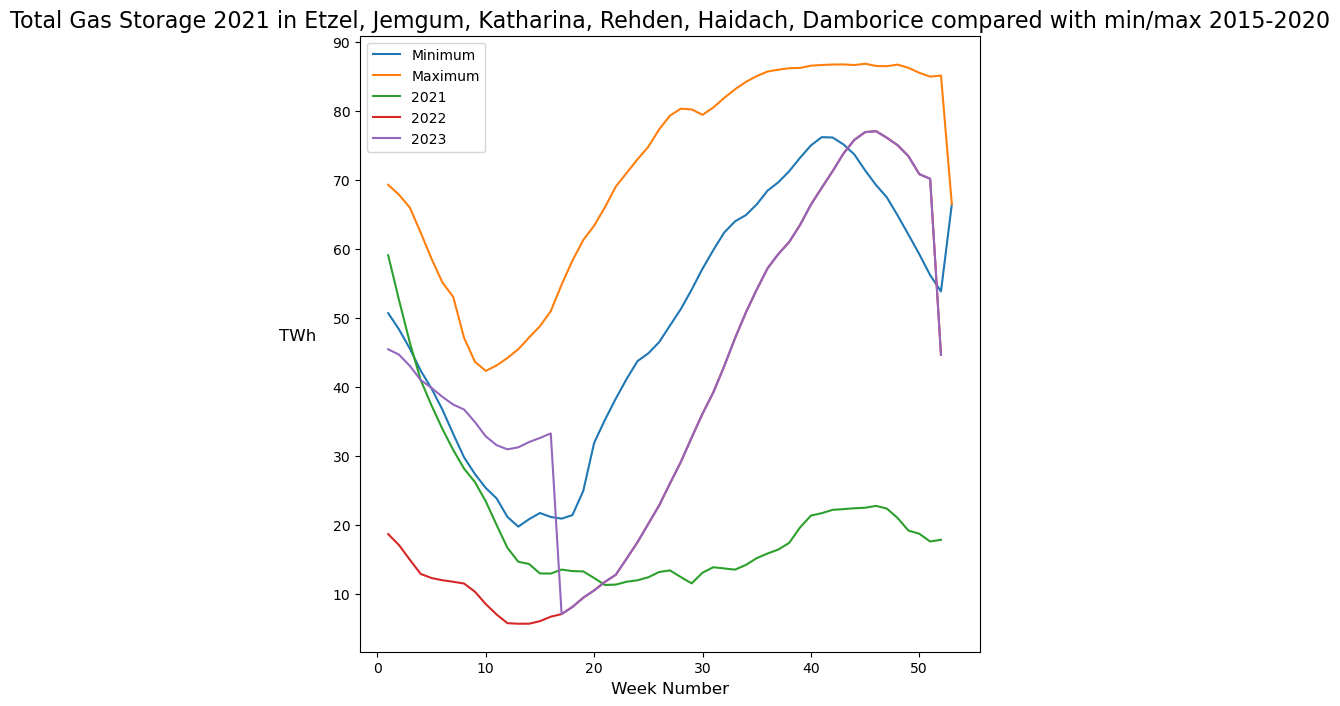

In [93]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(minvalues,label='Minimum')
ax.plot(maxvalues,label='Maximum')
# ax.plot(avgvalues,label='Average')
ax.plot(values2021,label='2021')
ax.plot(values2022,label='2022')
ax.plot(values2023,label='2023')

plt.title('Total Gas Storage 2021 in Etzel, Jemgum, Katharina, Rehden, Haidach, Damborice compared with min/max 2015-2020',fontsize='16')
plt.ylabel('TWh',fontsize=12,rotation=0,labelpad=25)
plt.xlabel('Week Number',fontsize=12,rotation=0)
plt.legend()
plt.show()
fig.savefig('figures/Gazprom storage (monthly).png',dpi=300,bbox_inches="tight")

# Quality Assurance

In [74]:
# Set the most recent date for which we have observations
last_date = str(today- timedelta(2))

In [75]:
#url = 'https://agsi.gie.eu/api/data/21X000000001160J/AT'
# url = Points_APIs.iloc[0,5]
# r = requests.get(url)
# data = r.json()

In [78]:
# These are normally the two APIs creating problems

# UGS Dambořice
# url = 'https://agsi.gie.eu/api/data/21W000000000102F/CZ/27X-MORAVIAGS--E'
# r = requests.get(url)
# print(r.status_code)    #500 means that the server encountered an unexpected condition that prevented it from fulfilling the request. This error is usually returned by the server when no other error code is suitable.

# # UGS Oude Statenzijl ETZEL Crystal
# url = 'https://agsi.gie.eu/api/data/21W000000000013E/DE/21X000000001125L'
# r = requests.get(url)
# print(r.status_code)     # The HTTP Status 200 (OK) status code indicates that the request has been processed successfully on the server. 

# UGS Etzel ESE (Gas Union Storage)
#Not existing

In [79]:
# Gazprom Germany 
Etzel = ['UGS Oude Statenzijl ETZEL Crystal', 'UGS Etzel EGL (Equinor Storage Deutschland)',
         'UGS Etzel ESE (Gas Union Storage)', 'UGS Etzel ESE (OMV)',
         'UGS Etzel Erdgas Lager EGL', 'UGS Etzel ESE (Uniper Energy Storage)', 'UGS Etzel ESE (VGS)']
Jemgum   = ['UGS Jemgum H (astora)', 'VSP NORD (Rehden, Jemgum)', 'UGS Jemgum H (EWE)', 'UGS Jemgum H (VGS)']
Katharina = 'UGS Katharina'
Rehden = 'UGS Rehden'
# Gazprom Austria
Haidach = ['UGS Haidach (astora)', 'UGS Haidach (GSA)']
# Gazprom CZ
Damborice ='UGS Dambořice'

In [80]:
df

,values,injection,withdrawal,fillness,status,Max Storage,country,name
dates,,,,,,,,
2015-01-01,4.7256,0.00,0.0,95.44,C,4.9514,NL,UGS Alkmaar
2015-01-01,9.2460,0.00,65.1,71.48,C,12.9350,FR,VGS SEDIANE B (Gournay-sur-Aronde)
2015-01-01,17.7634,0.00,7.1,64.21,C,27.6667,NL,UGS Grijpskerk *
2015-01-01,9.1526,1.32,13.0,81.72,C,11.2000,DE,UGS Bierwang
2015-01-01,19.3538,0.00,104.4,69.20,C,27.9698,AT,VGS OMV Gas Storage Pool (Tallesbrunn & Schönk...
...,...,...,...,...,...,...,...,...
2022-11-20,14.2222,0.00,0.0,99.88,C,14.2390,DE,UGS Epe Uniper H-Gas
2022-11-20,8.0500,13.15,11.6,99.08,C,8.1250,DE,UGS Jemgum H (astora)
2022-11-20,2.0954,0.00,4.1,98.36,C,2.1303,DE,UGS Epe Trianel


In [81]:
# df = df.set_index(pd.DatetimeIndex(df['dates']))
df_QA = df

In [82]:
df_QA

,values,injection,withdrawal,fillness,status,Max Storage,country,name
dates,,,,,,,,
2015-01-01,4.7256,0.00,0.0,95.44,C,4.9514,NL,UGS Alkmaar
2015-01-01,9.2460,0.00,65.1,71.48,C,12.9350,FR,VGS SEDIANE B (Gournay-sur-Aronde)
2015-01-01,17.7634,0.00,7.1,64.21,C,27.6667,NL,UGS Grijpskerk *
2015-01-01,9.1526,1.32,13.0,81.72,C,11.2000,DE,UGS Bierwang
2015-01-01,19.3538,0.00,104.4,69.20,C,27.9698,AT,VGS OMV Gas Storage Pool (Tallesbrunn & Schönk...
...,...,...,...,...,...,...,...,...
2022-11-20,14.2222,0.00,0.0,99.88,C,14.2390,DE,UGS Epe Uniper H-Gas
2022-11-20,8.0500,13.15,11.6,99.08,C,8.1250,DE,UGS Jemgum H (astora)
2022-11-20,2.0954,0.00,4.1,98.36,C,2.1303,DE,UGS Epe Trianel


In [83]:
converter=0.0103
converter_GWh = converter* 1000
df_QA['storage in M3m'] = df_QA['values']/converter
df_QA['injection in M3m'] = df_QA['injection']/converter_GWh
df_QA['withdrawal in M3m'] = df_QA['withdrawal']/converter_GWh
df_QA['Max Storage in M3m'] = df_QA['Max Storage']/converter

In [84]:
key_param = ["storage in M3m","injection in M3m","withdrawal in M3m","Max Storage in M3m"]

###  Etzel

In [85]:
Etzel = ['UGS Oude Statenzijl ETZEL Crystal', 'UGS Etzel EGL (Equinor Storage Deutschland)',
         'UGS Etzel ESE (Gas Union Storage)', 'UGS Etzel ESE (OMV)',
         'UGS Etzel Erdgas Lager EGL', 'UGS Etzel ESE (Uniper Energy Storage)', 'UGS Etzel ESE (VGS)']

In [86]:
df_Etzel = df_QA[df_QA.name.isin(Etzel)==True]
# del df_Etzel['dates']
df_Etzel = df_Etzel.groupby('dates')[key_param].sum().reset_index()
df_Etzel = df_Etzel.set_index(pd.DatetimeIndex(df_Etzel['dates']))

In [87]:
df_Etzel

,dates,storage in M3m,injection in M3m,withdrawal in M3m,Max Storage in M3m
dates,,,,,
2015-01-01,2015-01-01,2368.699029,0.000000,11.155340,3052.233010
2015-01-02,2015-01-02,2355.592233,0.000000,13.106796,3052.233010
2015-01-03,2015-01-03,2348.572816,2.052427,9.077670,3052.233010
2015-01-04,2015-01-04,2342.378641,2.085437,8.281553,3052.233010
2015-01-05,2015-01-05,2320.980583,0.000000,21.407767,3052.233010
...,...,...,...,...,...
2022-11-16,2022-11-16,2978.572816,3.903883,0.087379,2971.533981
2022-11-17,2022-11-17,2978.184466,0.000000,0.388350,2992.310680
2022-11-18,2022-11-18,2979.533981,1.581553,0.233010,2992.310680


In [88]:
df_Etzel[df_Etzel['dates']=='2019-12-01']

,dates,storage in M3m,injection in M3m,withdrawal in M3m,Max Storage in M3m
dates,,,,,
2019-12-01,2019-12-01,3029.446602,0.332039,2.300971,3078.058252


In [89]:
df_QA[(df_QA['name']=='UGS Etzel EGL (Equinor Storage Deutschland)') & (df_QA.index =='2022-01-16')]

,values,injection,withdrawal,fillness,status,Max Storage,country,name,storage in M3m,injection in M3m,withdrawal in M3m,Max Storage in M3m
dates,,,,,,,,,,,,
2022-01-16,1.4051,0.0,0.0,64.3,C,2.1851,DE,UGS Etzel EGL (Equinor Storage Deutschland),136.417476,0.0,0.0,212.145631


In [90]:
df_QA[(df_QA['name']=='UGS Etzel ESE (OMV)') & (df_QA.index=='2022-01-16')]

,values,injection,withdrawal,fillness,status,Max Storage,country,name,storage in M3m,injection in M3m,withdrawal in M3m,Max Storage in M3m
dates,,,,,,,,,,,,
2022-01-16,2.9251,0.0,13.5,55.24,C,5.295,DE,UGS Etzel ESE (OMV),283.990291,0.0,1.31068,514.07767


In [87]:
df_QA[(df_QA['name']=='UGS Etzel Erdgas Lager EGL') & (df_QA.index=='2022-01-16')]

,values,injection,withdrawal,fillness,status,Max Storage,country,name,storage in M3m,injection in M3m,withdrawal in M3m,Max Storage in M3m
dates,,,,,,,,,,,,
2022-01-16,5.5982,0.0,226.7,49.96,C,11.2062,DE,UGS Etzel Erdgas Lager EGL,543.514563,0.0,22.009709,1087.980583


In [88]:
df_QA[(df_QA['name']=='UGS Etzel ESE (Uniper Energy Storage)') & (df_QA.index=='2022-01-16')]

,values,injection,withdrawal,fillness,status,Max Storage,country,name,storage in M3m,injection in M3m,withdrawal in M3m,Max Storage in M3m
dates,,,,,,,,,,,,
2022-01-16,6.9164,0.0,73.9,59.07,C,11.7095,DE,UGS Etzel ESE (Uniper Energy Storage),671.495146,0.0,7.174757,1136.84466


In [89]:
df_QA[(df_QA['name']=='UGS Etzel ESE (VGS)') & (df_QA.index=='2022-01-16')]

,values,injection,withdrawal,fillness,status,Max Storage,country,name,storage in M3m,injection in M3m,withdrawal in M3m,Max Storage in M3m
dates,,,,,,,,,,,,
2022-01-16,0.9468,4.99,0.0,60.49,C,1.5652,DE,UGS Etzel ESE (VGS),91.92233,0.484466,0.0,151.961165


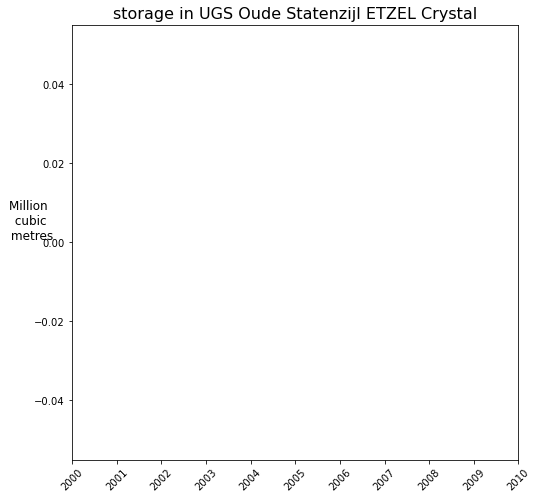

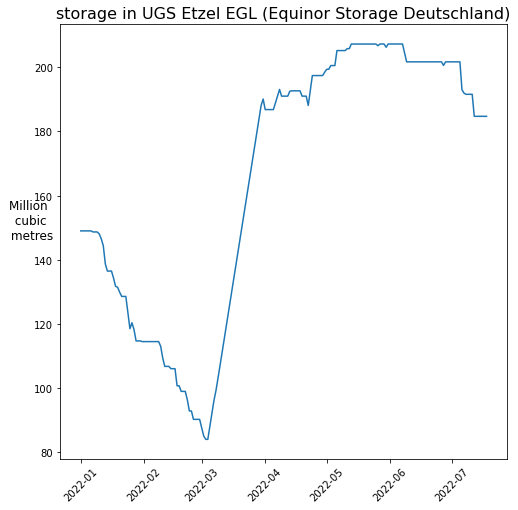

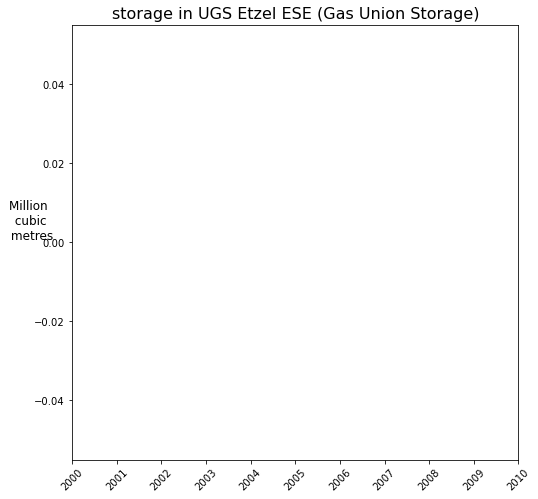

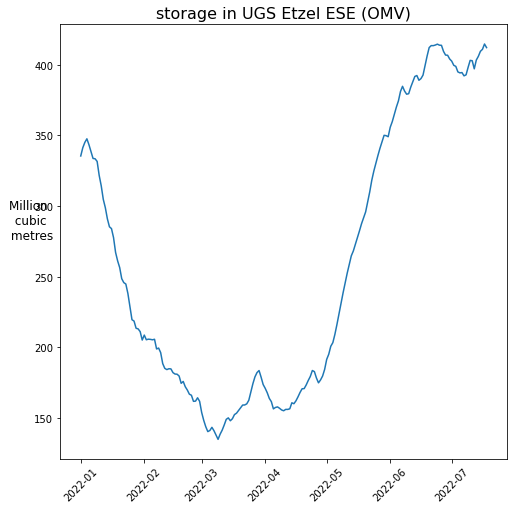

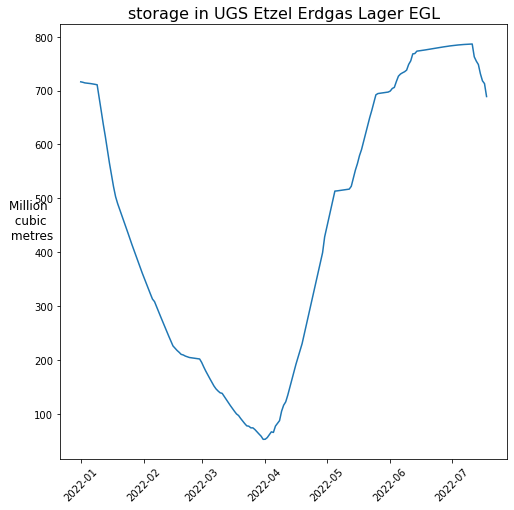

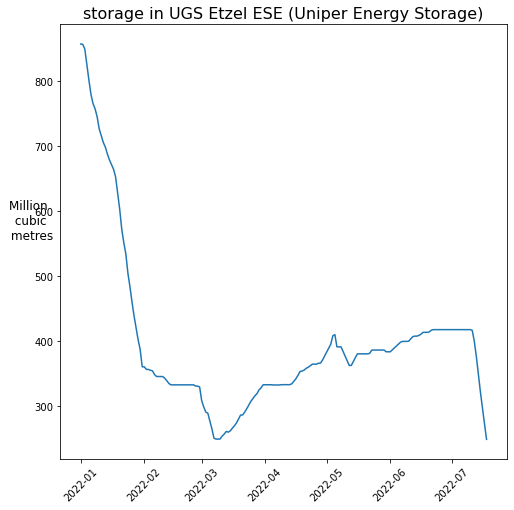

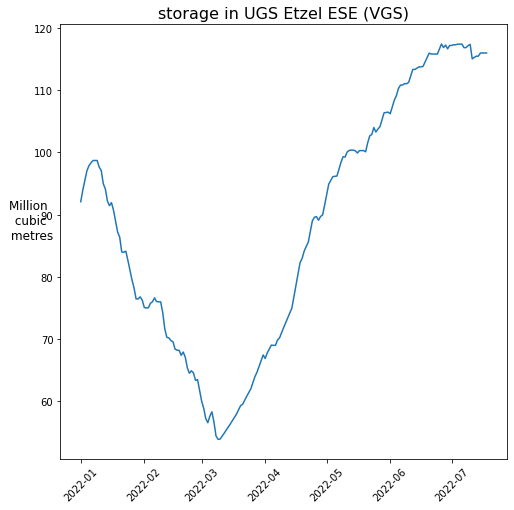

In [90]:
for points in Etzel:
    cdtemp = df[df['name'] == points]['2022-01-01':'2022-07-18']
#     cdplot = cdtemp.groupby(pd.Grouper(freq='D'))#['2021-11-10':]

#     Ddata['{}'.format(country)] = cdplot #add data to Dataframe for export. 

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.plot(cdtemp['values']/converter)

    plt.xticks(rotation=45)
    plt.title('storage in {}'.format(points),fontsize='16')
    plt.ylabel('Million \n cubic \n metres',fontsize=12,rotation=0)

    plt.show()
#     fig.savefig('figures/DAILY_{}_imports.png'.format(country),dpi=300,bbox_inches="tight")

In [110]:
df_QA

,values,injection,withdrawal,fillness,status,Max Storage,country,name,storage in M3m,injection in M3m,withdrawal in M3m,Max Storage in M3m
dates,,,,,,,,,,,,
2015-01-01,9.7547,1.37,68.8,64.51,C,15.1222,AT,"RAG Storage Pool (Puchkirchen / Haag, Aigelsbr...",947.058252,0.133010,6.679612,1468.174757
2015-01-01,8.3960,0.00,9.0,71.66,C,11.7160,DE,UGS Etzel Erdgas Lager EGL,815.145631,0.000000,0.873786,1137.475728
2015-01-01,13.2805,9.10,145.6,65.60,C,20.2433,DE,UGS Nüttermoor H aggregated data prior to 7 Ap...,1289.368932,0.883495,14.135922,1965.368932
2015-01-01,0.0000,0.00,0.0,0.00,C,0.0000,DE,UGS Epe (KGE),0.000000,0.000000,0.000000,0.000000
2015-01-01,19.4600,18.36,205.6,64.61,C,30.1182,SK,UGS Láb (incl. Gajary baden),1889.320388,1.782524,19.961165,2924.097087
...,...,...,...,...,...,...,...,...,...,...,...,...
2022-07-18,10.2591,0.00,12.6,75.94,C,13.5090,DE,UGS Epe Uniper H-Gas,996.029126,0.000000,1.223301,1311.553398
2022-07-18,10.1004,31.09,1.6,88.44,C,11.4203,FR,"VGS SALINE (Tersanne, Etrez, Manosque)",980.621359,3.018447,0.155340,1108.766990
2022-07-18,1.0505,1.98,0.0,72.85,C,1.4420,DE,UGS Etzel ESE (MET),101.990291,0.192233,0.000000,140.000000


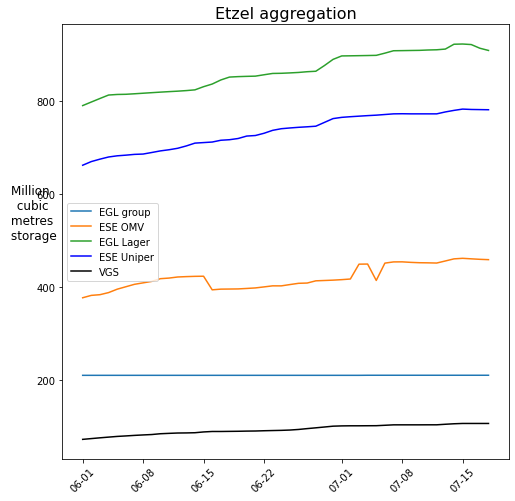

In [94]:
Etzel = ['UGS Oude Statenzijl ETZEL Crystal', 'UGS Etzel EGL (Equinor Storage Deutschland)',
         'UGS Etzel ESE (Gas Union Storage)', 'UGS Etzel ESE (OMV)',
         'UGS Etzel Erdgas Lager EGL', 'UGS Etzel ESE (Uniper Energy Storage)', 'UGS Etzel ESE (VGS)']

startdate = '2019-06-01'
enddate = '2019-07-18'

## List of considered plants 
Crystal = df_QA[df_QA['name'] == 'UGS Oude Statenzijl ETZEL Crystal']
Crystalplot = Crystal['storage in M3m'][startdate:enddate]

EGL_Group = df_QA[df_QA['name'] == 'UGS Etzel EGL (Equinor Storage Deutschland)']
EGLplot = EGL_Group['storage in M3m'][startdate:enddate]

ESE_GUS = df_QA[df_QA['name'] == 'UGS Etzel ESE (Gas Union Storage)']
ESE_GUSplot = ESE_GUS['storage in M3m'][startdate:enddate]

ESE_OMV = df_QA[df_QA['name'] == 'UGS Etzel ESE (OMV)']
ESE_OMVplot = ESE_OMV['storage in M3m'][startdate:enddate]

EGL_Lager = df_QA[df_QA['name'] == 'UGS Etzel Erdgas Lager EGL']
EGL_Lagerplot = EGL_Lager['storage in M3m'][startdate:enddate]

ESE_Uniper = df_QA[df_QA['name'] == 'UGS Etzel ESE (Uniper Energy Storage)']
ESE_Uniperplot = ESE_Uniper['storage in M3m'][startdate:enddate]

VGS = df_QA[df_QA['name'] == 'UGS Etzel ESE (VGS)']
VGSplot = VGS['storage in M3m'][startdate:enddate]

## Code for figure plot
fig, ax = plt.subplots(figsize=(8, 8))

# ax.plot(Crystalplot,label='Crystal',linestyle=':',marker='o')
ax.plot(EGLplot,label='EGL group')
# ax.plot(ESE_GUSplot,label='ESE GUS',linestyle=':', marker='o')
ax.plot(ESE_OMVplot,label='ESE OMV')
ax.plot(EGL_Lagerplot,label='EGL Lager')
ax.plot(ESE_Uniperplot,label='ESE Uniper', color='b')
ax.plot(VGSplot,label='VGS',color='black')

# ax.plot(Crystalplot+EGLplot+ESE_GUSplot+ESE_OMVplot+EGL_Lagerplot+ESE_Uniperplot+VGSplot,label='Total')

date_form1 = DateFormatter("%m-%d")
ax.xaxis.set_major_formatter(date_form1)
# ax.xaxis.set_major_locator(ticker.MultipleLocator(1))

plt.xticks(rotation=45)
plt.title('Etzel aggregation',fontsize='16')
plt.ylabel('Million \n cubic \n metres \n storage',fontsize=12,rotation=0)
plt.legend(loc='best')

plt.show()

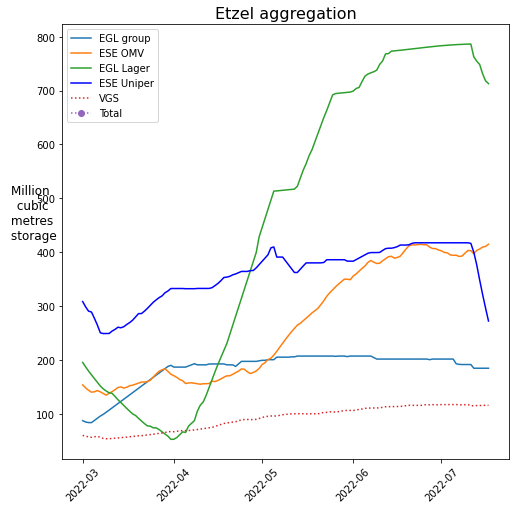

In [170]:
Etzel = ['UGS Oude Statenzijl ETZEL Crystal', 'UGS Etzel EGL (Equinor Storage Deutschland)',
         'UGS Etzel ESE (Gas Union Storage)', 'UGS Etzel ESE (OMV)',
         'UGS Etzel Erdgas Lager EGL', 'UGS Etzel ESE (Uniper Energy Storage)', 'UGS Etzel ESE (VGS)']

startdate = '2022-03-01'
enddate = '2022-07-17'

## List of considered plants 
Crystal = df_QA[df_QA['name'] == 'UGS Oude Statenzijl ETZEL Crystal']
Crystalplot = Crystal['storage in M3m'][startdate:enddate]

EGL_Group = df_QA[df_QA['name'] == 'UGS Etzel EGL (Equinor Storage Deutschland)']
EGLplot = EGL_Group['storage in M3m'][startdate:enddate]

ESE_GUS = df_QA[df_QA['name'] == 'UGS Etzel ESE (Gas Union Storage)']
ESE_GUSplot = ESE_GUS['storage in M3m'][startdate:enddate]

ESE_OMV = df_QA[df_QA['name'] == 'UGS Etzel ESE (OMV)']
ESE_OMVplot = ESE_OMV['storage in M3m'][startdate:enddate]

EGL_Lager = df_QA[df_QA['name'] == 'UGS Etzel Erdgas Lager EGL']
EGL_Lagerplot = EGL_Lager['storage in M3m'][startdate:enddate]

ESE_Uniper = df_QA[df_QA['name'] == 'UGS Etzel ESE (Uniper Energy Storage)']
ESE_Uniperplot = ESE_Uniper['storage in M3m'][startdate:enddate]

VGS = df_QA[df_QA['name'] == 'UGS Etzel ESE (VGS)']
VGSplot = VGS['storage in M3m'][startdate:enddate]

## Code for figure plot
fig, ax = plt.subplots(figsize=(8, 8))

# ax.plot(Crystalplot,label='Crystal',linestyle=':',marker='o')
ax.plot(EGLplot,label='EGL group')
# ax.plot(ESE_GUSplot,label='ESE GUS',linestyle=':', marker='o')
ax.plot(ESE_OMVplot,label='ESE OMV')
ax.plot(EGL_Lagerplot,label='EGL Lager')
ax.plot(ESE_Uniperplot,label='ESE Uniper',color='b')
ax.plot(VGSplot,label='VGS',linestyle=':')

# ax.plot(Crystalplot+EGLplot+ESE_GUSplot+ESE_OMVplot+EGL_Lagerplot+ESE_Uniperplot+VGSplot,label='Total',linestyle=':',marker='o')

date_form1 = DateFormatter("%m-%d")
# ax.xaxis.set_major_formatter(date_form1)
# ax.xaxis.set_major_locator(ticker.MultipleLocator(1))

plt.xticks(rotation=45)
plt.title('Etzel aggregation',fontsize='16')
plt.ylabel('Million \n cubic \n metres \n storage',fontsize=12,rotation=0)
plt.legend(loc='best')

plt.show()

In [95]:
# Set the most recent date for which we have observations
last_date = str(today- timedelta(2))

### Jemug

In [96]:
Jemgum_ext   = ['UGS Jemgum H (astora)', 'VSP NORD (Rehden, Jemgum)', 'UGS Jemgum H (EWE)', 'UGS Jemgum H (VGS)']
Jemgum   = ['UGS Jemgum H (astora)', 'UGS Jemgum H (VGS)']

In [97]:
# 'UGS Jemgum H (astora)'  + 'UGS Jemgum H (VGS)' 
Jemug_sum = 166+684
Jemug_sum

850

In [98]:
df_Jemgum = df_QA[df_QA.name.isin(Jemgum)==True].copy()

In [99]:
df_Jemgum_fill = df_Jemgum[df_Jemgum.index==last_date]
from numpy import average
weighted_avg = round(average(df_Jemgum_fill['fillness'], weights = df_Jemgum_fill['Max Storage']),2)
weighted_avg # same as the FT article

67.85

In [100]:
df_Jemgum_fill

,values,injection,withdrawal,fillness,status,Max Storage,country,name,storage in M3m,injection in M3m,withdrawal in M3m,Max Storage in M3m
dates,,,,,,,,,,,,
2022-08-07,1.5771,2.84,0.0,97.76,C,1.6131,DE,UGS Jemgum H (VGS),153.116505,0.275728,0.0,156.611650
2022-08-07,5.0300,126.82,0.0,61.91,C,8.1250,DE,UGS Jemgum H (astora),488.349515,12.312621,0.0,788.834951


In [101]:
# del df_Jemgum['dates']
# df_Jemgum = df_Jemgum.groupby('dates')[key_param].sum().reset_index()
# df_Jemgum = df_Jemgum.set_index(pd.DatetimeIndex(df_Jemgum['dates']))

In [102]:
df_Jemgum[df_Jemgum.index==last_date]

,values,injection,withdrawal,fillness,status,Max Storage,country,name,storage in M3m,injection in M3m,withdrawal in M3m,Max Storage in M3m
dates,,,,,,,,,,,,
2022-08-07,1.5771,2.84,0.0,97.76,C,1.6131,DE,UGS Jemgum H (VGS),153.116505,0.275728,0.0,156.611650
2022-08-07,5.0300,126.82,0.0,61.91,C,8.1250,DE,UGS Jemgum H (astora),488.349515,12.312621,0.0,788.834951


In [103]:
df_QA[(df_QA['name']=='UGS Jemgum H (EWE)') & (df_QA.index==last_date)]

,values,injection,withdrawal,fillness,status,Max Storage,country,name,storage in M3m,injection in M3m,withdrawal in M3m,Max Storage in M3m
dates,,,,,,,,,,,,
2022-08-07,3.4336,11.1,5.9,100.0,C,3.3858,DE,UGS Jemgum H (EWE),333.359223,1.07767,0.572816,328.718447


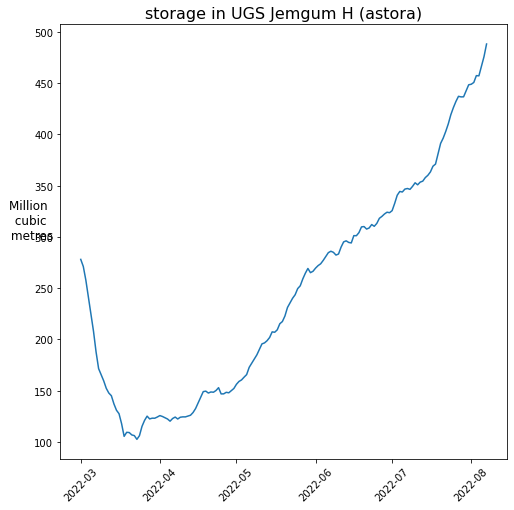

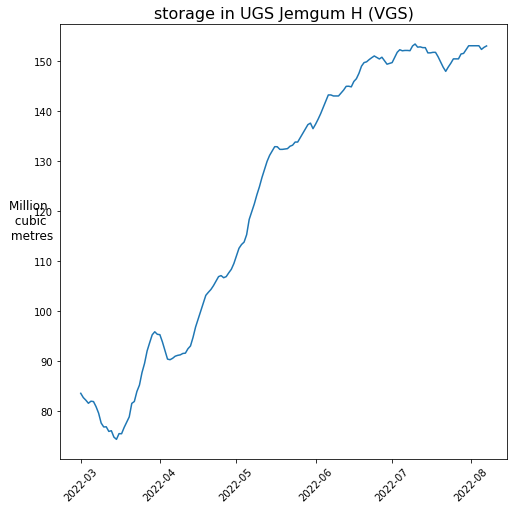

In [104]:
for points in Jemgum:
    cdtemp = df[df['name'] == points]['2022-03-01':last_date]

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.plot(cdtemp['values']/converter)

    plt.xticks(rotation=45)
    plt.title('storage in {}'.format(points),fontsize='16')
    plt.ylabel('Million \n cubic \n metres',fontsize=12,rotation=0)

    plt.show()
#     fig.savefig('figures/DAILY_{}_imports.png'.format(country),dpi=300,bbox_inches="tight")

### Haidach

In [105]:
df_Haidach = df_QA[df_QA.name.isin(Haidach)==True].copy()

In [106]:
# del df_Haidach['dates']
# df_Haidach = df_Haidach.groupby('dates')[key_param].sum().reset_index()
# df_Haidach = df_Haidach.set_index(pd.DatetimeIndex(df_Haidach['dates']))

In [107]:
df_Haidach[df_Haidach.index==last_date]

,values,injection,withdrawal,fillness,status,Max Storage,country,name,storage in M3m,injection in M3m,withdrawal in M3m,Max Storage in M3m
dates,,,,,,,,,,,,
2022-08-07,0.0009,0.0,0.0,100.00,C,0.0009,AT,UGS Haidach (GSA),0.087379,0.000000,0.0,0.087379
2022-08-07,7.3246,134.3,0.0,39.36,C,18.6080,AT,UGS Haidach (astora),711.126214,13.038835,0.0,1806.601942


In [108]:
df_Haidach_fill = df_Haidach[df_Haidach.index==last_date]
from numpy import average
weighted_avg = round(average(df_Haidach_fill['fillness'], weights = df_Haidach_fill['Max Storage']),2)
weighted_avg # same as the FT article

39.36

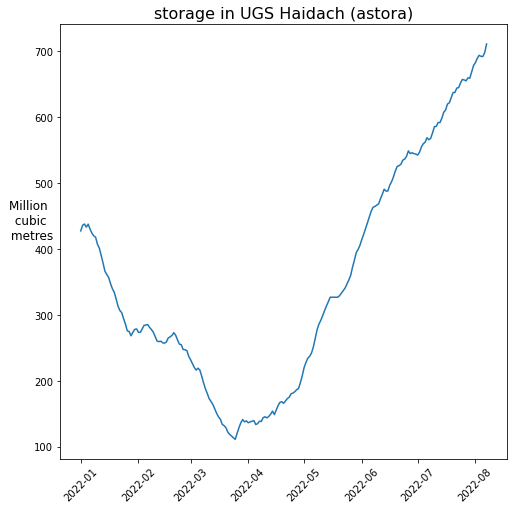

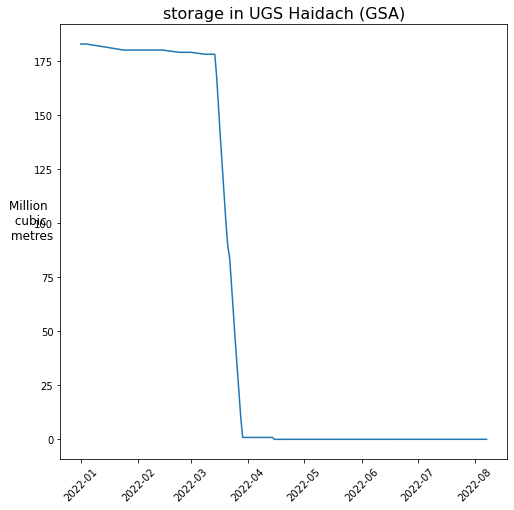

In [109]:
for points in Haidach:
    cdtemp = df[df['name'] == points]['2022-01-01':]

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.plot(cdtemp['values']/converter)

    plt.xticks(rotation=45)
    plt.title('storage in {}'.format(points),fontsize='16')
    plt.ylabel('Million \n cubic \n metres',fontsize=12,rotation=0)

    plt.show()
#     fig.savefig('figures/DAILY_{}_imports.png'.format(country),dpi=300,bbox_inches="tight")

### after Gazprom expropriation some reporting changed hat

#### Austria

In [116]:
new_Haidach = df[df['name']== 'RAG Storage Pool (Puchkirchen / Haag, Aigelsbrunn, Haidach 5, 7Fields-RAG)']

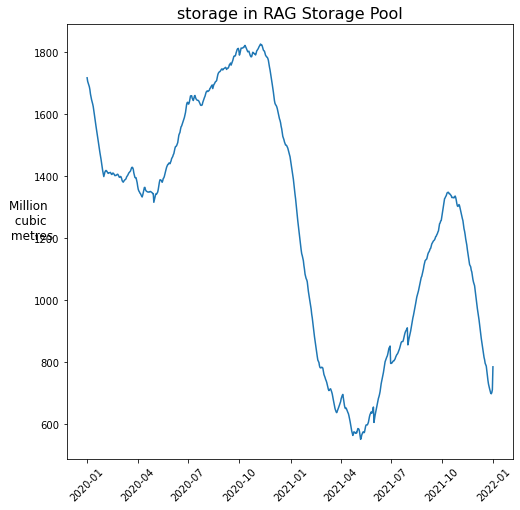

In [117]:
cdtemp = new_Haidach['2020-01-01':]

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(cdtemp['values']/converter)

plt.xticks(rotation=45)
plt.title('storage in RAG Storage Pool'.format(points),fontsize='16')
plt.ylabel('Million \n cubic \n metres',fontsize=12,rotation=0)

plt.show()
#     fig.savefig(

### Katharina

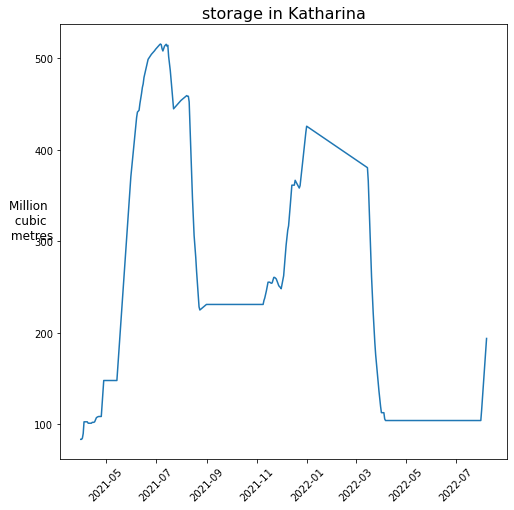

In [114]:
cdtemp = df[df['name'] == 'UGS Katharina']['2019-01-01':]

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(cdtemp['values']/converter)

plt.xticks(rotation=45)
plt.title('storage in Katharina',fontsize='16')
plt.ylabel('Million \n cubic \n metres',fontsize=12,rotation=0)

plt.show()
#     fig.savefig('figures/DAILY_{}_imports.png'.format(country),dpi=300,bbox_inches="tight")

In [149]:
df[df['name'] == 'UGS Katharina']['2022-01-01':]

,values,injection,withdrawal,fillness,status,Max Storage,country,name,storage in M3m,injection in M3m,withdrawal in M3m,Max Storage in M3m
dates,,,,,,,,,,,,
2022-01-01,4.3767,0.0,6.3,79.84,C,5.4815,DE,UGS Katharina,424.922330,0.0,0.61165,532.184466
2022-01-02,4.3704,0.0,6.3,79.73,C,5.4815,DE,UGS Katharina,424.310680,0.0,0.61165,532.184466
2022-01-03,4.3641,0.0,6.3,79.37,C,5.4981,DE,UGS Katharina,423.699029,0.0,0.61165,533.796117
2022-01-04,4.3578,0.0,6.3,79.26,C,5.4981,DE,UGS Katharina,423.087379,0.0,0.61165,533.796117
2022-01-05,4.3515,0.0,6.3,79.15,C,5.4981,DE,UGS Katharina,422.475728,0.0,0.61165,533.796117
...,...,...,...,...,...,...,...,...,...,...,...,...
2022-07-14,1.0721,0.0,0.0,19.36,C,5.5391,DE,UGS Katharina,104.087379,0.0,0.00000,537.776699
2022-07-15,1.0721,0.0,0.0,19.36,C,5.5391,DE,UGS Katharina,104.087379,0.0,0.00000,537.776699
2022-07-16,1.0721,0.0,0.0,19.36,C,5.5391,DE,UGS Katharina,104.087379,0.0,0.00000,537.776699


### Rehden

In [154]:
last_date = str(today- timedelta(2))

In [155]:
df_QA[(df_QA['name']=='UGS Rehden') & (df_QA.index==last_date)]
# same as FT article

,values,injection,withdrawal,fillness,status,Max Storage,country,name,storage in M3m,injection in M3m,withdrawal in M3m,Max Storage in M3m
dates,,,,,,,,,,,,
2022-07-18,14.8076,325.25,0.0,33.9,C,43.68,DE,UGS Rehden,1437.631068,31.57767,0.0,4240.776699


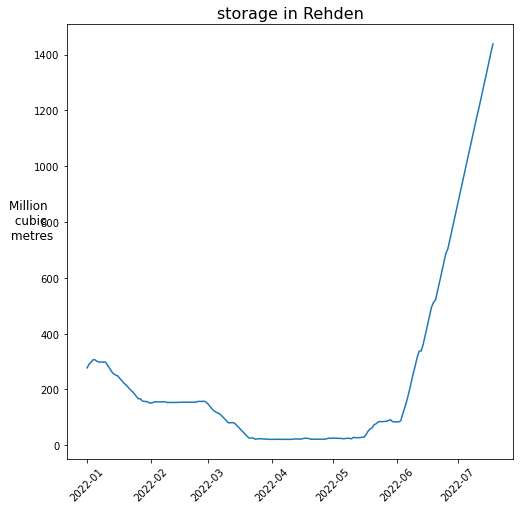

In [164]:
cdtemp = df[df['name'] == 'UGS Rehden']['2022-01-01':]

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(cdtemp['values']/converter)

plt.xticks(rotation=45)
plt.title('storage in Rehden',fontsize='16')
plt.ylabel('Million \n cubic \n metres',fontsize=12,rotation=0)

plt.show()
#     fig.savefig('figures/DAILY_{}_imports.png'.format(country),dpi=300,bbox_inches="tight")

### Dambořice

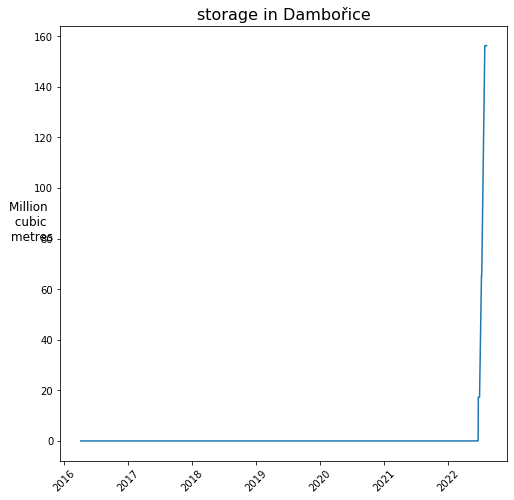

In [112]:
#Dambořice
cdtemp = df[df['name'] == 'UGS Dambořice'][:]

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(cdtemp['values']/converter)

plt.xticks(rotation=45)
plt.title('storage in Dambořice',fontsize='16')
plt.ylabel('Million \n cubic \n metres',fontsize=12,rotation=0)

plt.show()

# Rubbish?

In [165]:
Gazprom_aggregate = [Etzel,Jemgum,Katharina,Rehden,Haidach,Damborice]

In [156]:
Gazprom_aggregate = pd.DataFrame(Gazprom_aggregate)
Gazprom_aggregate.to_excel(r'C:\Users\giovanni.sgaravatti\OneDrive - Bruegel\Documents\Gas flow model\AGSI storage\Gazprom aggregate.xlsx')

In [89]:
Gazprom_APIs = pd.read_excel(r'C:\Users\giovanni.sgaravatti\OneDrive - Bruegel\Documents\Gas flow model\AGSI storage\Gazprom APIs.xlsx')

In [94]:
dates = []
values = []
injection = []
withdrawal =[]
percentage = []
status = []
max_storage = []
country = []
Name = []

for item in range(len(Gazprom_APIs)):
        url = Gazprom_APIs.iloc[item,5]
        try:
            r = requests.get(url)
            if r.status_code != 200:
                print(r.status_code)
                print(url)

            data = r.json()
            for x in data:
                #here we work with the APIs
                date = x['gasDayStartedOn']
                value = x['gasInStorage']
                inj = x['injection']
                withdr = x['withdrawal']
                percentages = x['full']
                statuses = x['status']
                Max_Storage = x['workingGasVolume']
                #here we work with the excel file
                countries = Points_APIs.iloc[item,0]
                Names = Points_APIs.iloc[item,4]


                dates.append(date)     
                values.append(value)
                injection.append(inj)
                withdrawal.append(withdr)
                percentage.append(percentages)
                status.append(statuses)
                max_storage.append(Max_Storage)
                country.append(countries)
                Name.append(Names)
        except Exception as e:
            print(e)

200
https://agsi.gie.eu/api/data/21W000000000013E/DE/21X000000001125L
200
https://agsi.gie.eu/api/data/21W000000000100J/DE/21X000000001368W
400
https://agsi.gie.eu/api/data/21W000000000055Z/DE/21X000000001090E
Expecting value: line 1 column 1 (char 0)
200
https://agsi.gie.eu/api/data/21W000000000056X/DE/25X-OMVGASSTORA5
200
https://agsi.gie.eu/api/data/21W000000000059R/DE/21X000000001127H
200
https://agsi.gie.eu/api/data/21W0000000000168/DE/21X000000001127H
200
https://agsi.gie.eu/api/data/21W000000000120D/DE/21X000000001138C
200
https://agsi.gie.eu/api/data/21W0000000001148/DE/21X000000001160J
200
https://agsi.gie.eu/api/data/21W0000000001261/DE/21X000000001160J
200
https://agsi.gie.eu/api/data/21W0000000000508/DE/21X0000000011756
200
https://agsi.gie.eu/api/data/21W000000000128Y/DE/21X000000001138C
200
https://agsi.gie.eu/api/data/21W0000000000281/DE/21X000000001297T
200
https://agsi.gie.eu/api/data/21Z000000000271O/DE/21X000000001160J
200
https://agsi.gie.eu/api/data/21W000000000126

In [95]:
df_Gazprom_check = pd.DataFrame()
df_Gazprom_check['dates'] = dates
df_Gazprom_check['values'] = values
df_Gazprom_check['injection'] = injection
df_Gazprom_check['withdrawal'] = withdrawal
df_Gazprom_check['fillness'] = percentage
df_Gazprom_check['status'] = status
df_Gazprom_check['Max Storage'] = max_storage
df_Gazprom_check['country'] = country
df_Gazprom_check['name'] = Name

In [102]:
# This doesn't work Unable to parse string "-" at position 11862
# Getting rid of observations for which we have no data
df_Gazprom_check = df[(df['status']!='N') & (df['status']!='E')]
# Getting rid of NaNa
df_Gazprom_check.replace('', np.NaN)  #we set missing values to the numpy notation, NaN - easier to work with. 
df_Gazprom_check.replace('-', np.NaN)
# #We need to set it to integer to work with. 

,dates,values,injection,withdrawal,fillness,status,Max Storage,country,name
0,2021-12-05,5.2567,24.02,10.62,46.33,C,11.3451,AT,UGS Haidach (astora)
1,2021-12-04,5.2433,0.00,33.09,46.22,C,11.3451,AT,UGS Haidach (astora)
2,2021-12-03,5.2764,0.00,68.87,46.51,C,11.3451,AT,UGS Haidach (astora)
3,2021-12-02,5.3453,0.00,105.84,47.12,C,11.3451,AT,UGS Haidach (astora)
4,2021-12-01,5.4511,0.00,46.45,48.05,C,11.3451,AT,UGS Haidach (astora)
...,...,...,...,...,...,...,...,...,...
277393,2015-01-06,4.6264,0.00,64.00,66.29,C,6.9794,SK,UGS Lab IV - Pozagas
277394,2015-01-05,4.6904,0.20,52.91,67.20,C,6.9794,SK,UGS Lab IV - Pozagas
277395,2015-01-04,4.7431,0.30,56.56,67.96,C,6.9794,SK,UGS Lab IV - Pozagas
277396,2015-01-03,4.7993,0.83,58.18,68.76,C,6.9794,SK,UGS Lab IV - Pozagas


In [157]:
Gazprom_countries =['AT','CZ', 'DE'] 

In [168]:
# EU_Gazprom = df[df['country'].isin(Gazprom_countries)]
# Gazprom_list = list(EU_Gazprom['name'].unique())
# Gazprom_list

In [162]:
# Gazprom_list = pd.DataFrame(Gazprom_list)
# Gazprom_list.to_excel(r'C:\Users\giovanni.sgaravatti\OneDrive - Bruegel\Documents\Gas flow model\AGSI storage\Gazprom list.xlsx')

## This works but calendar day (day 1 is the first of the month)

In [224]:
values_30_days['daily'] = range(1,32)  # I tried to be smart with groupby() by I didn't manage to
values_30_days = values_30_days.set_index(values_30_days['daily']) 
del values_30_days['daily']

<ipython-input-224-b1718657dfcd>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  values_30_days['daily'] = range(1,32)


In [28]:
Gas_value = df.groupby(['country','dates'])['values'].sum().reset_index()

In [31]:
Gas_value = Gas_value.set_index(pd.DatetimeIndex(Gas_value['dates']))

In [37]:
Gas_value[Gas_value['country']=='PL']

,country,dates,values
dates,,,
2011-01-01,PL,2011-01-01,6.30930.00000.00000.0000
2011-01-02,PL,2011-01-02,6.28720.00000.00000.0000
2011-01-03,PL,2011-01-03,6.21000.00000.00000.0000
2011-01-04,PL,2011-01-04,6.11070.00000.00000.0000
2011-01-05,PL,2011-01-05,5.97840.00000.00000.0000
...,...,...,...
2021-10-20,PL,2021-10-20,14.41798.753111.4439
2021-10-21,PL,2021-10-21,14.41798.780611.4439
2021-10-22,PL,2021-10-22,14.41798.766111.4431


C:\Users\giovanni.sgaravatti\Anaconda3\lib\site-packages\numpy\core\_asarray.py:171: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order, subok=True)


ConversionError: Failed to convert value(s) to axis units: array([           country       dates                    values
       dates
       2011-01-01      PL  2011-01-01  6.30930.00000.00000.0000
       2011-01-02      PL  2011-01-02  6.28720.00000.00000.0000
       2011-01-03      PL  2011-01-03  6.21000.00000.00000.0000
       2011-01-04      PL  2011-01-04  6.11070.00000.00000.0000
       2011-01-05      PL  2011-01-05  5.97840.00000.00000.0000
       2011-01-06      PL  2011-01-06  5.87910.00000.00000.0000
       2011-01-07      PL  2011-01-07  5.83500.00000.00000.0000
       2011-01-08      PL  2011-01-08  5.83500.00000.00000.0000
       2011-01-09      PL  2011-01-09  5.86810.00000.00000.0000
       2011-01-10      PL  2011-01-10  5.84600.00000.00000.0000
       2011-01-11      PL  2011-01-11  5.81290.00000.00000.0000
       2011-01-12      PL  2011-01-12  5.79090.00000.00000.0000
       2011-01-13      PL  2011-01-13  5.77980.00000.00000.0000
       2011-01-14      PL  2011-

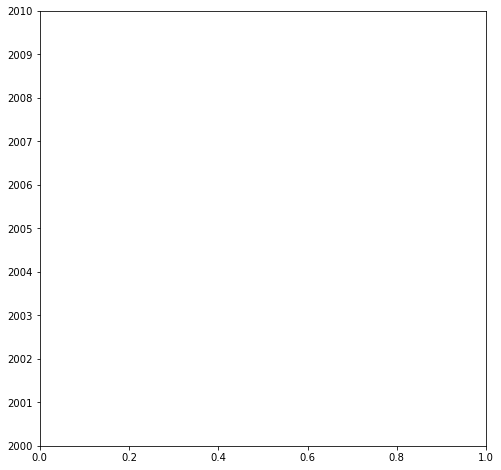

In [35]:
country = 'PL'
startdate = '2015-01'
enddate = '2020-12'

tick_spacing = 400
date_form = DateFormatter("%Y")

dfcountry = Gas_value[Gas_value['country'] == country]
                              
fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(dfcountry.groupby(pd.Grouper(freq='M')).values,label='value')

ax.xaxis.set_major_formatter(date_form)
ax.xaxis.set_major_locator(ticker.MultipleLocator(tick_spacing))
ax.yaxis.set_label_coords(-0.15,.45)

plt.title('Country: {} and measure: {}'.format(country,'value'),fontsize=20)
plt.ylabel('TWh',fontsize=12,rotation=0) 
                                                                   
plt.legend()
# fig.savefig('plantsM/{}.png'.format('Beregdaróc'),dpi=300,bbox_inches="tight")
# plt.show()
